<a href="https://colab.research.google.com/github/shaazmistry/predicting_star_quasers_galaxy/blob/main/og_emotion_recog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [ ]:
import os, numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

 Dataset Download

In [ ]:
import kagglehub
path = kagglehub.dataset_download("shuvoalok/raf-db-dataset")

TRAIN_DIR = TEST_DIR = None
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        TRAIN_DIR = os.path.join(root, 'train')
        TEST_DIR  = os.path.join(root, 'test')
        break
print("Train:", TRAIN_DIR)
print("Test: ", TEST_DIR)

Using Colab cache for faster access to the 'raf-db-dataset' dataset.
Train: /kaggle/input/raf-db-dataset/DATASET/train
Test:  /kaggle/input/raf-db-dataset/DATASET/test


Data Generators
Creates two ImageDataGenerators — one for training with augmentation (rotation, flip, zoom, brightness, shear) and one for testing with rescaling only. Loads images as 100×100 RGB. Sets EMOTIONS and NUM_CLASSES from the folder names.

In [ ]:
IMG_SIZE = 100; BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=20,
    width_shift_range=0.15, height_shift_range=0.15,
    horizontal_flip=True, zoom_range=0.15,
    shear_range=0.1, brightness_range=[0.75,1.25]
).flow_from_directory(TRAIN_DIR, target_size=(IMG_SIZE,IMG_SIZE),
    color_mode='rgb', batch_size=BATCH_SIZE, class_mode='categorical')

test_gen = ImageDataGenerator(rescale=1./255
).flow_from_directory(TEST_DIR, target_size=(IMG_SIZE,IMG_SIZE),
    color_mode='rgb', batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

EMOTIONS    = list(train_gen.class_indices.keys())
NUM_CLASSES = len(EMOTIONS)

# rename so charts code still works
train_generator = train_gen
test_generator  = test_gen
print("Classes:", EMOTIONS)

Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
Classes: ['1', '2', '3', '4', '5', '6', '7']


 Class Weights
Computes balanced class weights using sklearn so minority classes like Fear and Disgust receive higher loss penalty during training to compensate for their low sample counts.

In [ ]:
y_train = train_gen.classes
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))
print("Weights:", {EMOTIONS[i]: round(w,3) for i,w in class_weights.items()})

Weights: {'1': np.float64(1.359), '2': np.float64(6.238), '3': np.float64(2.445), '4': np.float64(0.367), '5': np.float64(0.884), '6': np.float64(2.487), '7': np.float64(0.695)}


Build Model
Defines the custom ResizeLayer. Builds the MobileNetV2 model with frozen backbone and custom classification head — GlobalAveragePooling, Dense 512, BatchNorm, Dropout 0.5, Dense 256, Dropout 0.3, Dense 7 Softmax.

In [ ]:
class ResizeLayer(tf.keras.layers.Layer):
    def call(self, x): return tf.image.resize(x, (96, 96))
    def get_config(self): return super().get_config()

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x      = ResizeLayer()(inputs)
base   = MobileNetV2(input_shape=(96,96,3), include_top=False, weights='imagenet')
base.trainable = False
x       = base(x, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(512, activation='relu')(x)
x       = BatchNormalization()(x)
x       = Dropout(0.5)(x)
x       = Dense(256, activation='relu')(x)
x       = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model   = Model(inputs, outputs)
print("Model built")

Model built


 Phase 1 Training
Compiles with Adam lr=1e-3 and label smoothing 0.15. Trains for up to 12 epochs with frozen backbone. EarlyStopping saves the best weights and ModelCheckpoint saves best_emotion_rafdb.keras.

In [ ]:
model.compile(
    optimizer=Adam(1e-3),
    loss=CategoricalCrossentropy(label_smoothing=0.15),
    metrics=['accuracy']
)

model.fit(
    train_gen, epochs=12,
    validation_data=test_gen,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
        ModelCheckpoint('best_emotion_rafdb.keras', save_best_only=True, verbose=1)
    ]
)
print("Done — model saved")

Epoch 1/12
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.2489 - loss: 2.3162
Epoch 1: val_loss improved from None to 1.70845, saving model to best_emotion_rafdb.keras

Epoch 1: finished saving model to best_emotion_rafdb.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 187s 469ms/step - accuracy: 0.2661 - loss: 2.1645 - val_accuracy: 0.3628 - val_loss: 1.7084
Epoch 2/12
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.3276 - loss: 1.8271
Epoch 2: val_loss did not improve from 1.70845
384/384 ━━━━━━━━━━━━━━━━━━━━ 136s 355ms/step - accuracy: 0.3312 - loss: 1.8166 - val_accuracy: 0.3621 - val_loss: 1.7336
Epoch 3/12
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.3688 - loss: 1.7381
Epoch 3: val_loss improved from 1.70845 to 1.68994, saving model to best_emotion_rafdb.keras

Epoch 3: finished saving model to best_emotion_rafdb.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 136s 354ms/step - accuracy: 0.3727 - loss: 1.7259 - val_accuracy: 0.3967 - val_loss: 1.6899
Epoch 4/12
384/384 ━━━━

Verify Model Saved

In [ ]:
print(os.path.exists('best_emotion_rafdb.keras'))  # must print True

True


Load Best Model and Get Predictions
Loads the saved best model. Resets test generator and runs model.predict to get probability scores for all test images. Computes y_pred and y_true for evaluation.

In [ ]:
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_generator.classes
print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)

96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 264ms/step
y_true: (3068,)
y_pred: (3068,)


Setup for Charts


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc,
                              precision_recall_curve, average_precision_score)
from tensorflow.keras.utils import to_categorical

CHARTS_DIR = "evaluation_charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

COLORS = ['#E63946','#2DC653','#9B5DE5','#F4D35E','#8D99AE','#4895EF','#F77F00']

# pre-compute these once — all charts below use them
report     = classification_report(y_true, y_pred, target_names=EMOTIONS, output_dict=True)
cm         = confusion_matrix(y_true, y_pred)
cm_norm    = cm.astype('float') / cm.sum(axis=1, keepdims=True)
y_true_bin = to_categorical(y_true, NUM_CLASSES)
print("Setup done")

Setup done


 Class Distribution
Bar chart showing how many images exist per emotion in train and test splits side by side, revealing the class imbalance problem.

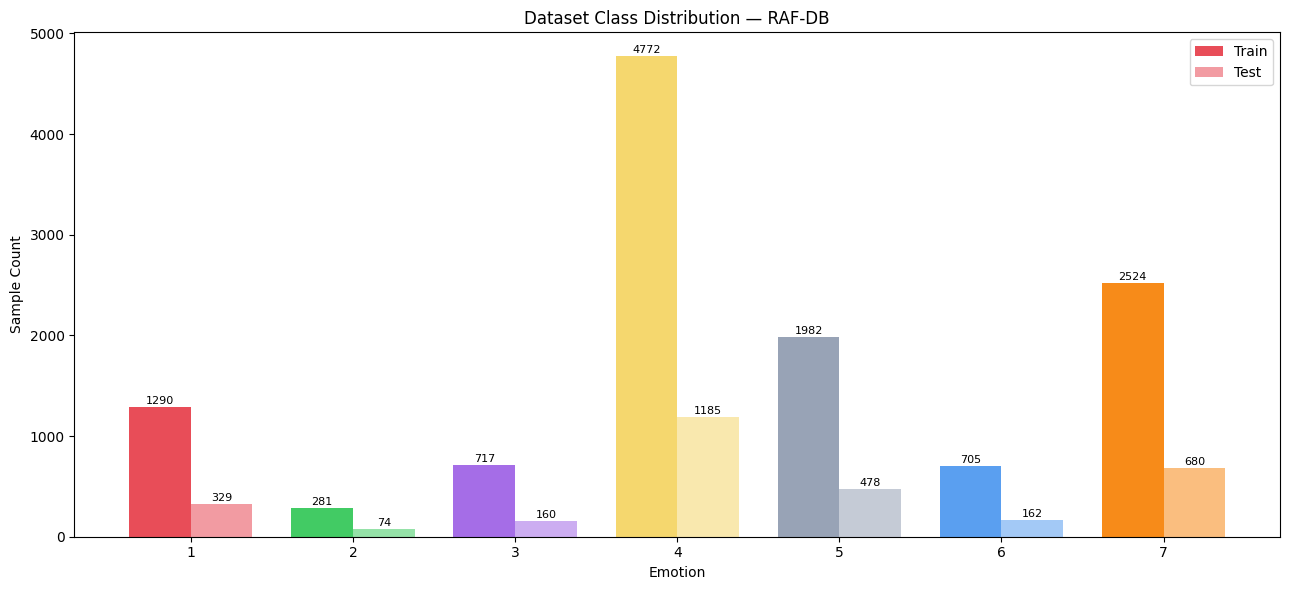

Saved chart 1


In [ ]:
plt.rcdefaults()
y_train_counts = np.bincount(train_generator.classes)
y_test_counts  = np.bincount(test_generator.classes)
x = np.arange(NUM_CLASSES); w = 0.38
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w/2, y_train_counts, w, color=COLORS, alpha=0.9, label='Train')
b2 = ax.bar(x + w/2, y_test_counts,  w, color=COLORS, alpha=0.5, label='Test')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(EMOTIONS)
ax.set_title('Dataset Class Distribution — RAF-DB')
ax.set_xlabel('Emotion'); ax.set_ylabel('Sample Count'); ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved chart 1")

 Confusion Matrix
Two heatmaps side by side — left shows raw prediction counts, right shows row-normalised recall per class. Diagonal is correct predictions, off-diagonal is misclassifications.

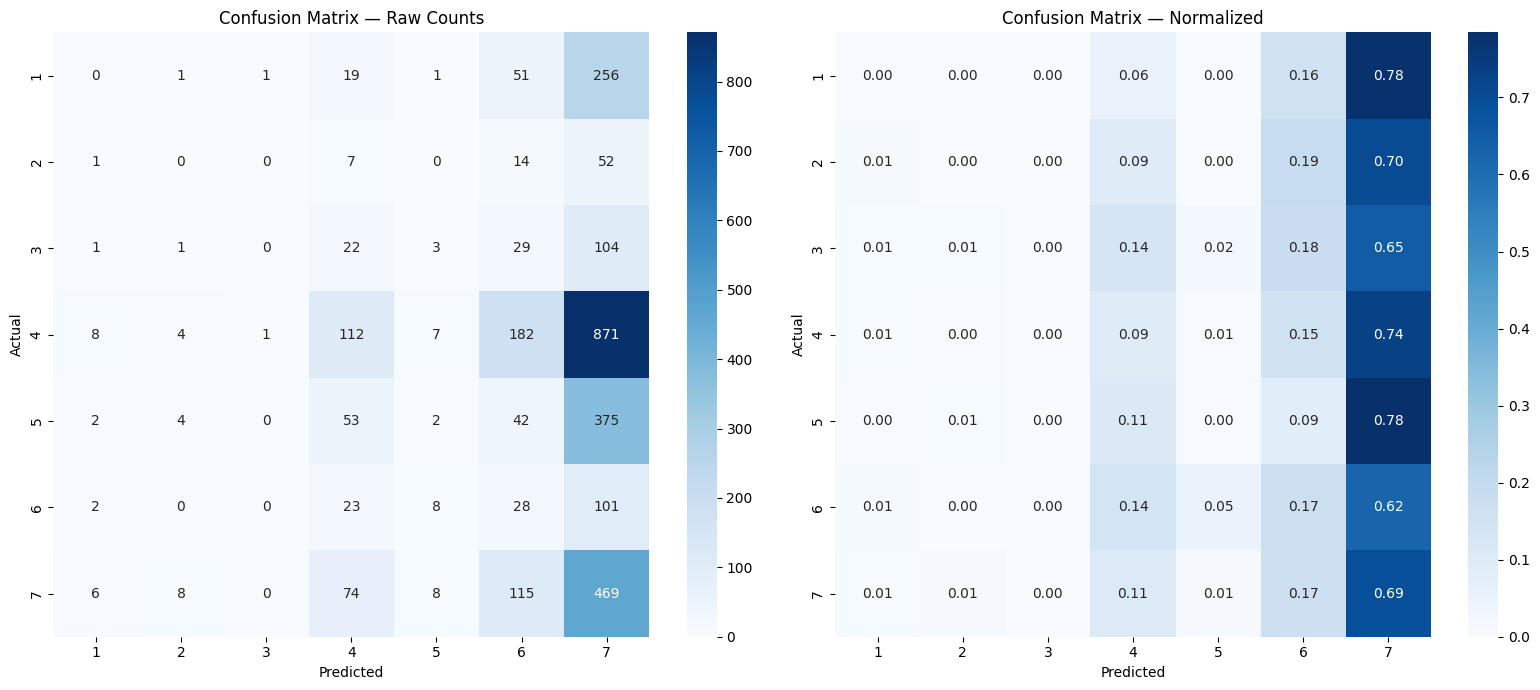

Saved chart 2


In [ ]:
plt.rcdefaults()
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Confusion Matrix — Raw Counts', 'Confusion Matrix — Normalized'],
    ['d', '.2f']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/02_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved chart 2")

Per-Class Metrics
Grouped bar chart showing Precision, Recall, and F1-Score for each emotion class with 0.80 and 0.90 reference lines and values annotated above each bar.

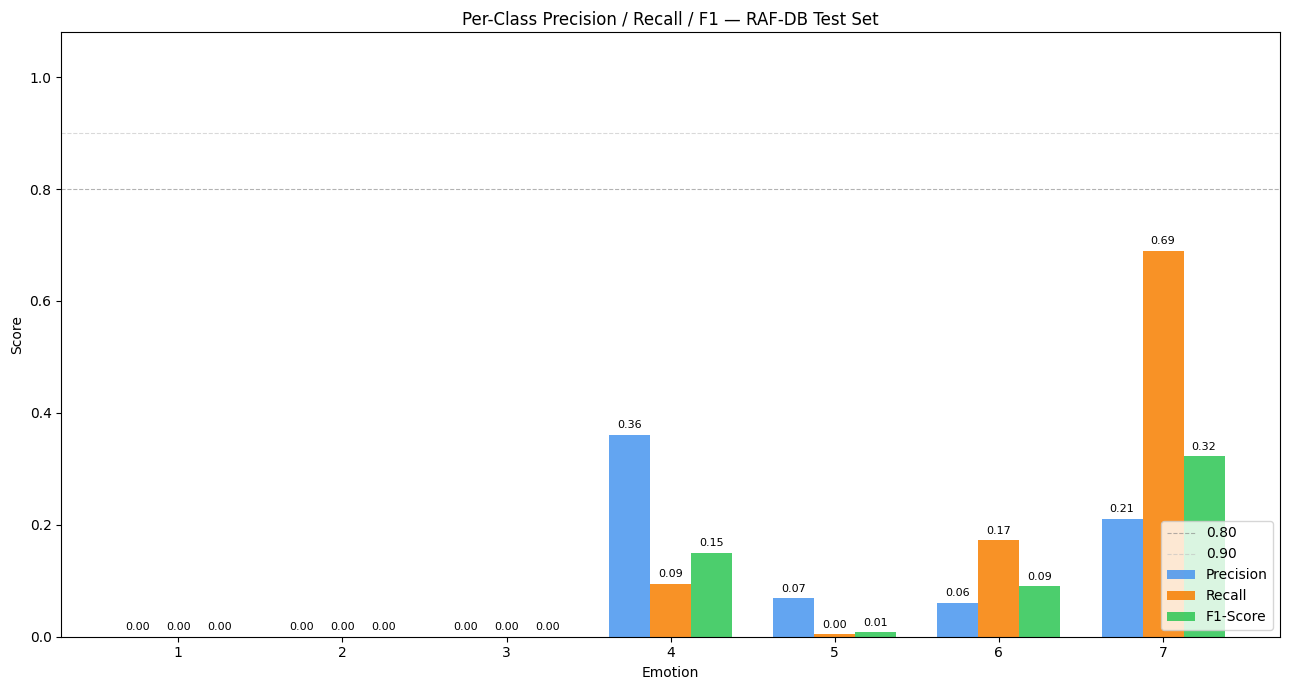

Saved chart 3


In [ ]:
plt.rcdefaults()
precisions = [report[e]['precision'] for e in EMOTIONS]
recalls    = [report[e]['recall']    for e in EMOTIONS]
f1s        = [report[e]['f1-score']  for e in EMOTIONS]
x = np.arange(NUM_CLASSES); w = 0.25
fig, ax = plt.subplots(figsize=(13, 7))
for i, (vals, lbl, color) in enumerate(zip(
    [precisions, recalls, f1s],
    ['Precision', 'Recall', 'F1-Score'],
    ['#4895EF', '#F77F00', '#2DC653']
)):
    bars = ax.bar(x + (i-1)*w, vals, w, label=lbl, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)
ax.axhline(y=0.8, color='gray',   ls='--', lw=0.8, alpha=0.6, label='0.80')
ax.axhline(y=0.9, color='silver', ls='--', lw=0.8, alpha=0.6, label='0.90')
ax.set_xticks(x); ax.set_xticklabels(EMOTIONS)
ax.set_ylim(0, 1.08)
ax.set_title('Per-Class Precision / Recall / F1 — RAF-DB Test Set')
ax.set_xlabel('Emotion'); ax.set_ylabel('Score'); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/03_per_class_metrics.png", dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved chart 3")


ROC Curves
One-vs-rest ROC curve per emotion class plus macro-averaged ROC. AUC value shown in legend for each. Higher curve means better class discrimination.

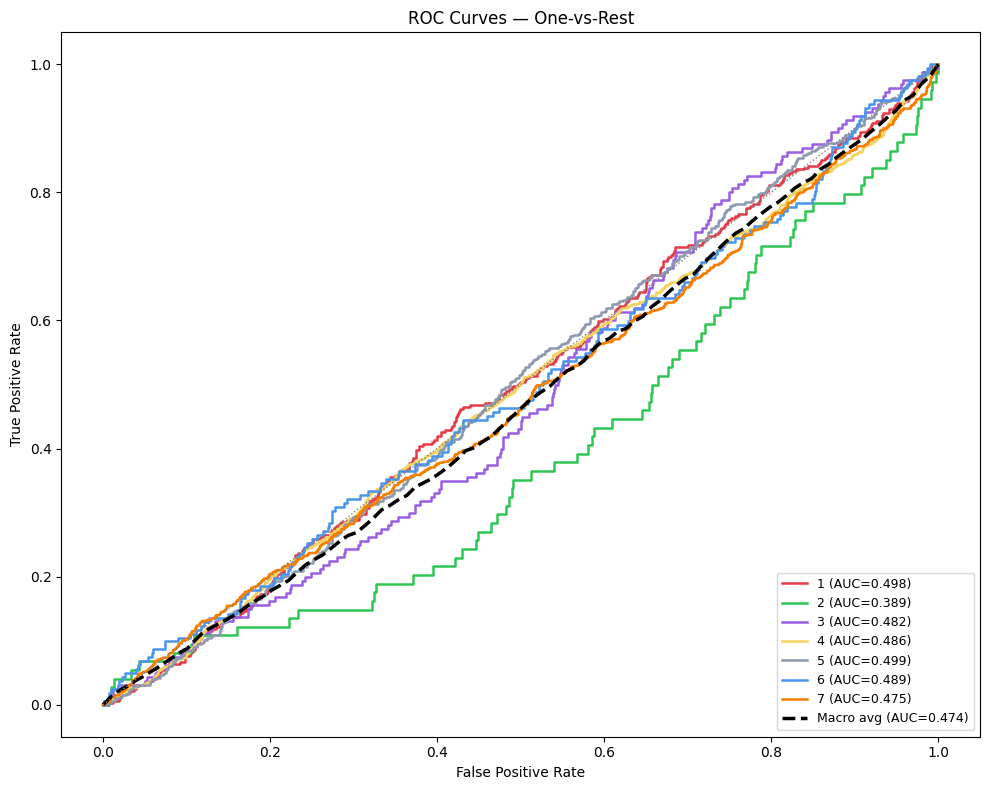

Saved chart 4


In [ ]:
plt.rcdefaults()
fig, ax = plt.subplots(figsize=(10, 8))
fpr_grid = np.linspace(0, 1, 100); mean_tpr = np.zeros(100)
for i, (emotion, color) in enumerate(zip(EMOTIONS, COLORS)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    mean_tpr   += np.interp(fpr_grid, fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.8, label=f'{emotion} (AUC={roc_auc:.3f})')
mean_tpr /= NUM_CLASSES
macro_auc = auc(fpr_grid, mean_tpr)
ax.plot(fpr_grid, mean_tpr, 'k--', lw=2.5, label=f'Macro avg (AUC={macro_auc:.3f})')
ax.plot([0,1],[0,1], 'gray', lw=1, ls=':')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-vs-Rest'); ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/04_roc_curves.png", dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved chart 4")

Precision-Recall Curves
One-vs-rest Precision-Recall curve per emotion with Average Precision score. More informative than ROC for imbalanced classes like Fear and Disgust.

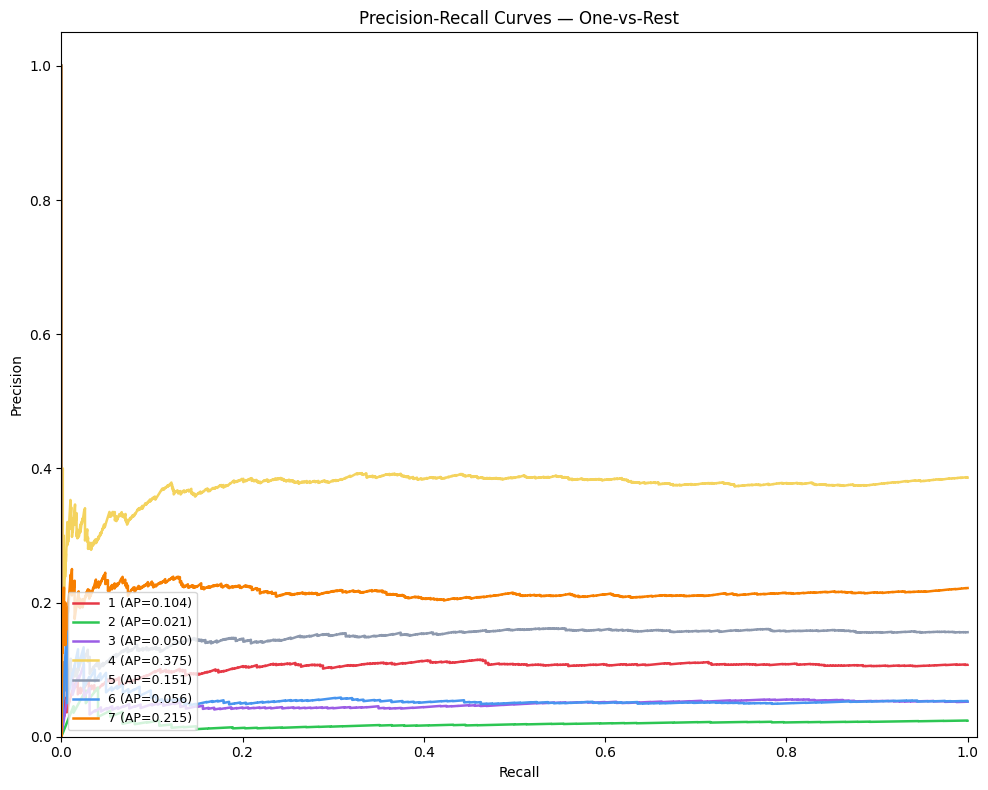

Saved chart 5


In [ ]:
plt.rcdefaults()
fig, ax = plt.subplots(figsize=(10, 8))
for i, (emotion, color) in enumerate(zip(EMOTIONS, COLORS)):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
    ap           = average_precision_score(y_true_bin[:, i], y_pred_probs[:, i])
    ax.plot(rec, prec, color=color, lw=1.8, label=f'{emotion} (AP={ap:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_xlim(0, 1.01); ax.set_ylim(0, 1.05)
ax.set_title('Precision-Recall Curves — One-vs-Rest')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/05_precision_recall.png", dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved chart 5")

 Confidence Distribution
Eight small histograms showing model confidence scores split into correct predictions (class colour) and wrong predictions (red) for each emotion class.

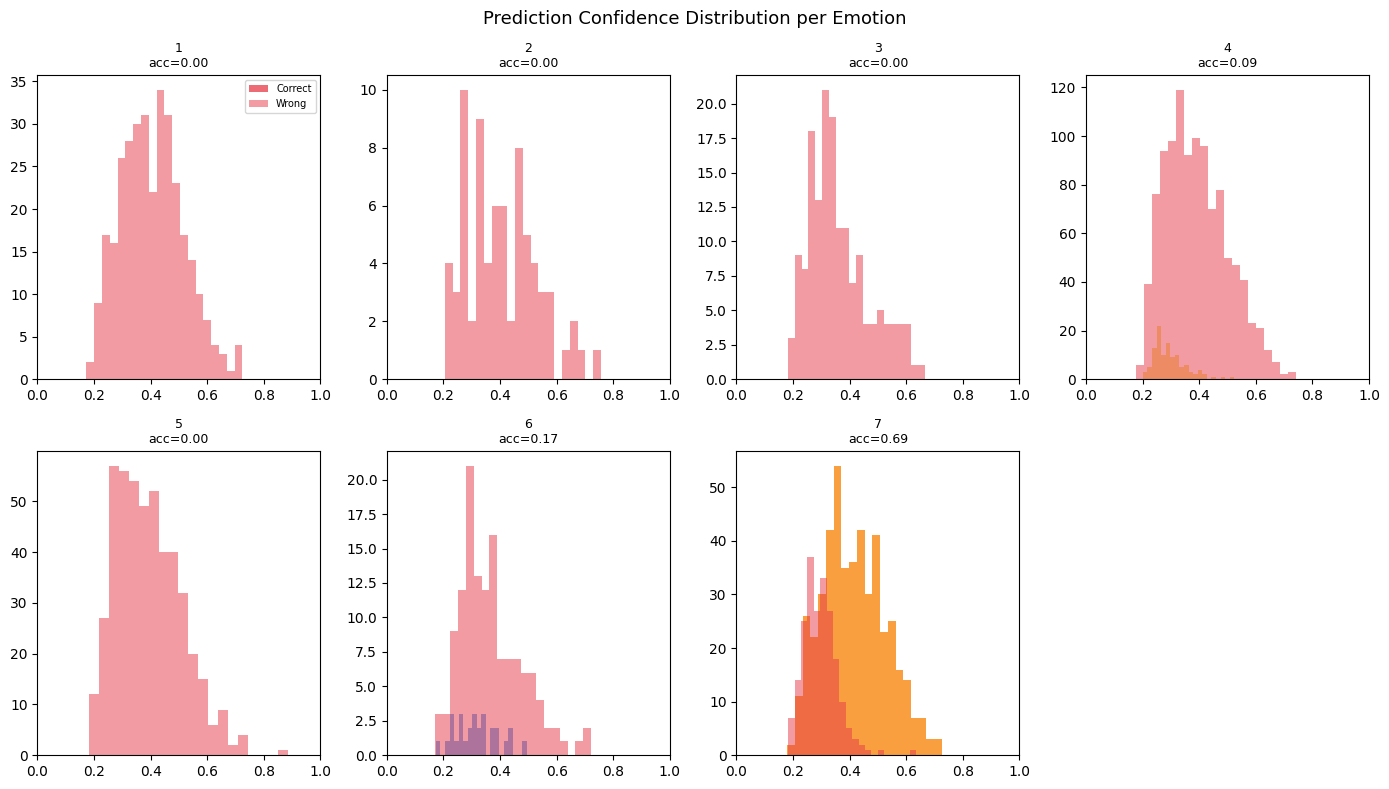

Saved chart 6


In [ ]:
plt.rcdefaults()
max_confs = np.max(y_pred_probs, axis=1)
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()
for i, emotion in enumerate(EMOTIONS):
    mask    = (y_true == i)
    confs   = max_confs[mask]
    correct = (y_pred[mask] == i)
    axes[i].hist(confs[correct],  bins=20, color=COLORS[i], alpha=0.75, label='Correct')
    axes[i].hist(confs[~correct], bins=20, color='#E63946', alpha=0.5,  label='Wrong')
    axes[i].set_title(f'{emotion}\nacc={correct.mean():.2f}', fontsize=9)
    axes[i].set_xlim(0, 1)
    if i == 0: axes[i].legend(fontsize=7)
axes[-1].axis('off')
plt.suptitle('Prediction Confidence Distribution per Emotion', fontsize=13)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/06_confidence_distribution.png", dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved chart 6")

Accuracy Heatmap
YlOrRd colour heatmap of the normalised confusion matrix. Dark red diagonal means strong performance, lighter off-diagonal means confusion between those two classes.

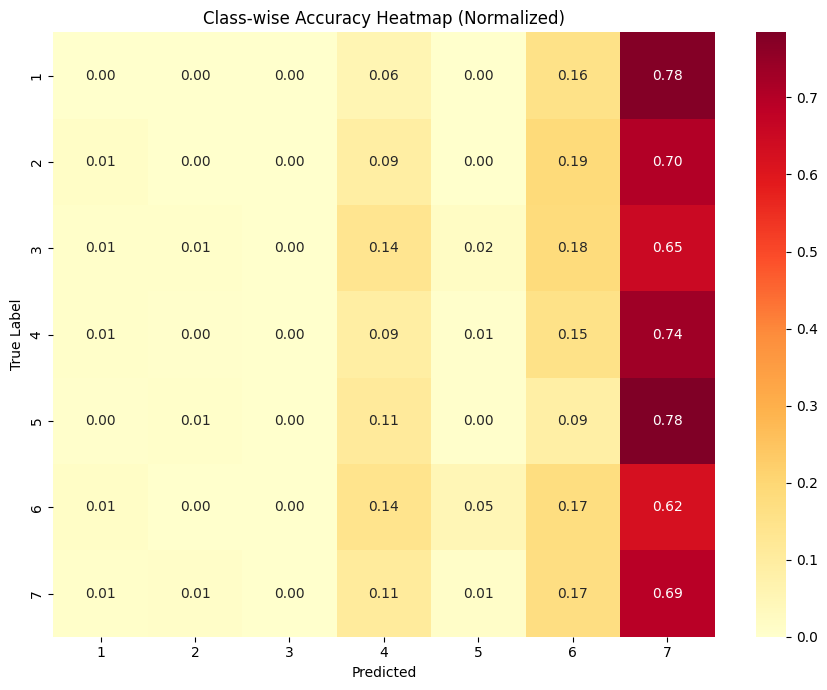

Saved chart 7


In [ ]:
plt.rcdefaults()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax)
ax.set_title('Class-wise Accuracy Heatmap (Normalized)')
ax.set_xlabel('Predicted'); ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/07_accuracy_heatmap.png", dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved chart 7")

Summary Table
Clean table showing Overall Accuracy, Macro F1, Weighted F1, Macro AUC, total test samples, and number of classes in one place.


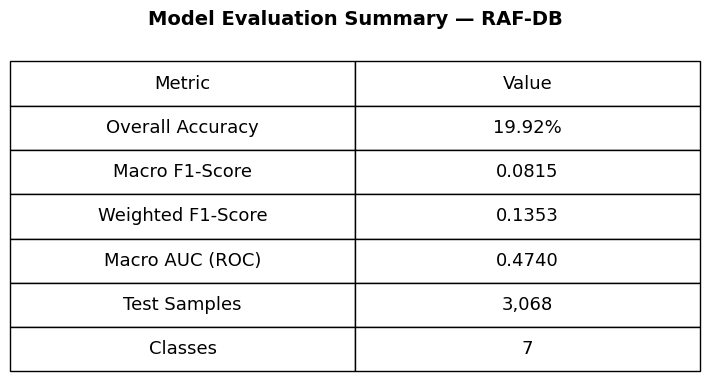

Saved chart 8


In [ ]:
plt.rcdefaults()
overall_acc = (y_pred == y_true).mean()
macro_f1    = report['macro avg']['f1-score']
weighted_f1 = report['weighted avg']['f1-score']
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
tbl = ax.table(
    cellText=[
        ["Overall Accuracy",  f"{overall_acc*100:.2f}%"],
        ["Macro F1-Score",    f"{macro_f1:.4f}"],
        ["Weighted F1-Score", f"{weighted_f1:.4f}"],
        ["Macro AUC (ROC)",   f"{macro_auc:.4f}"],
        ["Test Samples",      f"{len(y_true):,}"],
        ["Classes",           str(NUM_CLASSES)],
    ],
    colLabels=["Metric", "Value"],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(13); tbl.scale(1.5, 2.5)
ax.set_title('Model Evaluation Summary — RAF-DB', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/08_summary.png", dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved chart 8")

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Get full report
report = classification_report(y_true, y_pred, target_names=EMOTIONS, output_dict=True)

# Build table
rows = []
for emotion in EMOTIONS:
    rows.append({
        'Emotion':   emotion,
        'Precision': f"{report[emotion]['precision']:.4f}",
        'Recall':    f"{report[emotion]['recall']:.4f}",
        'F1-Score':  f"{report[emotion]['f1-score']:.4f}",
        'Support':   int(report[emotion]['support'])
    })

# Add summary rows
for key in ['macro avg', 'weighted avg']:
    rows.append({
        'Emotion':   key.title(),
        'Precision': f"{report[key]['precision']:.4f}",
        'Recall':    f"{report[key]['recall']:.4f}",
        'F1-Score':  f"{report[key]['f1-score']:.4f}",
        'Support':   int(report[key]['support'])
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

     Emotion Precision Recall F1-Score  Support
           1    0.0000 0.0000   0.0000      329
           2    0.0000 0.0000   0.0000       74
           3    0.0000 0.0000   0.0000      160
           4    0.3613 0.0945   0.1498     1185
           5    0.0690 0.0042   0.0079      478
           6    0.0607 0.1728   0.0899      162
           7    0.2105 0.6897   0.3226      680
   Macro Avg    0.1002 0.1373   0.0815     3068
Weighted Avg    0.2002 0.1992   0.1353     3068


Save and Download


In [ ]:
print("\nAll charts:")
for f in sorted(os.listdir(CHARTS_DIR)):
    print(f"  {f}")

import zipfile, shutil
with zipfile.ZipFile("charts.zip", "w") as zf:
    for f in sorted(os.listdir(CHARTS_DIR)):
        if f.endswith(".png"):
            zf.write(f"{CHARTS_DIR}/{f}", f)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    shutil.copy("charts.zip", "/content/drive/MyDrive/charts.zip")
    print("Copied to Google Drive — download from drive.google.com")
except:
    pass


All charts:
  01_class_distribution.png
  02_confusion_matrix.png
  03_per_class_metrics.png
  04_roc_curves.png
  05_precision_recall.png
  06_confidence_distribution.png
  07_accuracy_heatmap.png
  08_summary.png
